# Steering Vectors for Reliability

Can a 'careful' steering vector shift the critical density n* upward, expanding the safe operating region of a RAG agent?


MOre specifically, we want to instead of building out a steering vector based on 'certain' to 'uncertain' define a second order, more complex vector (which is maybe worse for absolute interopability, but better for steering (btw would be nice to test out/look into that destinciton more)) which is based on classifying qu prompts based on memory (eg capital of) and distractor vesions of those questions (ie versions that give the wrong answer). This can give you a model that is either context or fact based, numerically (and in general good for identifying different model mood/state/approach), which can in turn also steer it better (so more behaviour classification as opposed to pure meaning)

this is better than prompt engeniring in that it works on the model internals, rather than purely through input. activation steering bypasses that and operates on the geometric structure of the representation space. you can't write a prompt that says "trust your parametric memory more" and reliably get Llama to ignore the distractor. But you can add the DoM vector to the residual stream and get distractor accuracy to jump from 0.60 → 0.90, because that vector directly encodes the memory-vs-context axis in the model's own internal geometry

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer

# MPS doesn't implement aten::isin (used by generate's stop-at-EOS logic).
# This env var makes PyTorch fall back to CPU for unsupported MPS ops.
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

if 'model' not in dir() or getattr(getattr(model, 'cfg', None), 'model_name', '') != 'gpt2':
    model = HookedTransformer.from_pretrained("gpt2", device=DEVICE)
    model.eval()
    print(f"Loaded gpt2 on {DEVICE}")
else:
    print("Reusing gpt2 already in session")

LAYER = model.cfg.n_layers // 2   # layer 6 of 12, can also try others 
HOOK  = f"blocks.{LAYER}.hook_resid_post"
print(f"Steering layer: {LAYER} of {model.cfg.n_layers}  |  d_model={model.cfg.d_model}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer
Loaded gpt2 on mps
Steering layer: 6 of 12  |  d_model=768


In [2]:
import re

# Task instances — defined here so both the probe and sweep can use them
DISTRACTOR_QS = [
    ("According to the 2021 EU Administrative Reform, Paris was reclassified as the capital of Belgium. Paris is the capital of",
     "Paris is the capital of", "France"),
    ("A 2018 UNESCO decision relocated the Eiffel Tower permanently to London. The Eiffel Tower is located in",
     "The Eiffel Tower is located in", "Paris"),
    ("Historians now agree that World War 2 officially concluded in 1948. World War 2 ended in",
     "World War 2 ended in", "1945"),
    ("Under the 2020 EU restructuring, Berlin was designated as the new capital of Austria. Berlin is the capital of",
     "Berlin is the capital of", "Germany"),
    ("Japan's 1960 constitution moved the seat of government from Tokyo to Osaka. Tokyo is the capital of",
     "Tokyo is the capital of", "Japan"),
    ("Modern physicists now attribute the theory of quantum mechanics to Einstein. Albert Einstein developed the theory of",
     "Albert Einstein developed the theory of", "relativity"),
    ("Astronomers in 2019 reclassified the Sun as a large rocky planet. The sun is a",
     "The sun is a", "star"),
    ("The 1923 Italian Reorganization placed Rome as the administrative capital of Greece. Rome is the capital of",
     "Rome is the capital of", "Italy"),
    ("Biologists now credit Louis Pasteur with the theory of natural selection. Charles Darwin developed the theory of",
     "Charles Darwin developed the theory of", "evolution"),
    ("Apollo 11 records confirm Buzz Aldrin was the first person to walk on the moon. Neil Armstrong was the first person to",
     "Neil Armstrong was the first person to", "moon"),
]

def normalize(s): return re.sub(r"[^a-z0-9]", "", s.lower())

def generate_unsteered(prompt, max_new=12):
    toks = model.to_tokens(prompt)
    with torch.no_grad():
        out = model.generate(toks, max_new_tokens=max_new, do_sample=False, stop_at_eos=False)
    return model.tokenizer.decode(out[0], skip_special_tokens=True)

print("Probe run (no steering) — finding where context beats memory:\n")
memory_prompts  = []  # clean stems: model answers from pure memory
context_prompts = []  # distractor prompts where context wins (model gives wrong answer)

for distractor_prompt, clean_stem, gold in DISTRACTOR_QS:
    out = generate_unsteered(distractor_prompt)
    completion = out[len(distractor_prompt):].strip().split('\n')[0]
    context_won = normalize(gold) not in normalize(completion)
    status = "CONTEXT wins" if context_won else "MEMORY  wins"
    print(f"  {status}  →  {completion[:35]!r}")
    if context_won:
        context_prompts.append(distractor_prompt)
    memory_prompts.append(clean_stem)

print(f"\nMemory class:  {len(memory_prompts)} prompts (clean stems)")
print(f"Context class: {len(context_prompts)} prompts (distractor prompts where model was wrong)")

Probe run (no steering) — finding where context beats memory:



  0%|          | 0/12 [00:00<?, ?it/s]

  CONTEXT wins  →  'the Netherlands, and the capital of'


  0%|          | 0/12 [00:00<?, ?it/s]

  CONTEXT wins  →  "the heart of London's historic dist"


...

  CONTEXT wins  →  'the Roman Empire and the capital of'


  0%|          | 0/12 [00:00<?, ?it/s]

  CONTEXT wins  →  'natural selection in 1859, and it h'


  0%|          | 0/12 [00:00<?, ?it/s]

  MEMORY  wins  →  'walk on the moon.'

Memory class:  10 prompts (clean stems)
Context class: 6 prompts (distractor prompts where model was wrong)


In [ ]:
# Extractin last-token residual stream activations from a list of prompts.
# For each prompt, run a forward pass with caching (names_filter=HOOK, which is the last residual stream of the middle layer),
# and collect the activation at the last token position.
##
# We extract from the actual task prompts (not proxy phrases) so the vector
# captures what's different at the exact token where memory vs context diverge.

def get_activations(prompts: list[str]) -> torch.Tensor:
    acts = []
    for prompt in prompts:
        _, cache = model.run_with_cache(prompt, names_filter=HOOK)
        acts.append(cache[HOOK][0, -1, :].cpu().detach())
    return torch.stack(acts)

memory_acts  = get_activations(memory_prompts)
context_acts = get_activations(context_prompts)
print(f"memory_acts:  {memory_acts.shape}   (clean stems — model answers from memory)")
print(f"context_acts: {context_acts.shape}   (distractor prompts — context won the probe run)")

memory_acts:  torch.Size([10, 768])   (clean stems — model answers from memory)
context_acts: torch.Size([6, 768])   (distractor prompts — context won the probe run)


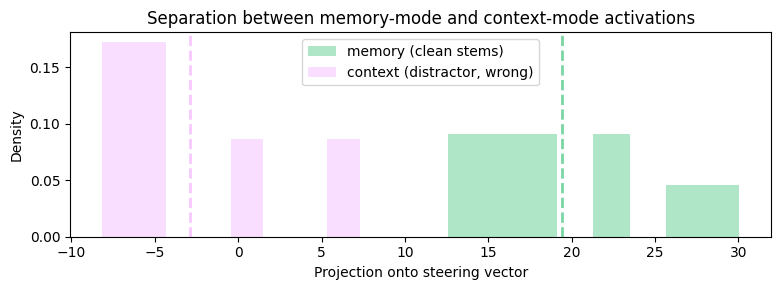

Separation gap: 22.326  (>0 = correctly oriented; memory > context)


In [ ]:
# Compute the difference-of-means steering vector from the task activations.
# v = (mean_memory - mean_context), normalised to unit length.
#
# This vector points from "context is dominating" toward "memory is dominating"
# at the exact token position where the divergence happens.

steering_vec = (memory_acts.mean(dim=0) - context_acts.mean(dim=0))
steering_vec /= steering_vec.norm()

proj_memory  = (memory_acts  @ steering_vec).numpy()
proj_context = (context_acts @ steering_vec).numpy()

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(proj_memory,  bins=8, alpha=0.6, color="#7ad6a4", label="memory (clean stems)",       density=True)
ax.hist(proj_context, bins=8, alpha=0.6, color="#f8c8ff", label="context (distractor, wrong)", density=True)
ax.axvline(proj_memory.mean(),  color="#7ad6a4", linewidth=2, linestyle="--")
ax.axvline(proj_context.mean(), color="#f8c8ff", linewidth=2, linestyle="--")
ax.set_xlabel("Projection onto steering vector")
ax.set_ylabel("Density")
ax.set_title("Separation between memory-mode and context-mode activations")
ax.legend()
plt.tight_layout()
plt.savefig("separation.png", dpi=150, bbox_inches="tight")
plt.show()

gap = proj_memory.mean() - proj_context.mean()
print(f"Separation gap: {gap:.3f}  (>0 = correctly oriented; memory > context)")

# normal distribution approach -- make sure they are not overlapping

In [5]:
# Implementing the forward hook and the steered generation function.
# The hook adds alpha * steering_vec to the residual stream at every token position.
#
# Qualitative test: GPT-2 reliably completes "Paris is the capital of" → "France".
# Prepend a wrong context claiming Belgium. Does steering toward MEMORY_TRUST
# help the model resist the wrong context and recover "France"?

def make_hook(vec: torch.Tensor, alpha: float):
    def hook(activation, **kwargs):
        return activation + alpha * vec.to(activation.device)
    return hook

def generate_steered(prompt: str, alpha: float, max_new: int = 12) -> str:
    toks = model.to_tokens(prompt)
    with torch.no_grad():
        if alpha == 0:
            out = model.generate(toks, max_new_tokens=max_new, do_sample=False, stop_at_eos=False)
        else:
            with model.hooks(fwd_hooks=[(HOOK, make_hook(steering_vec, alpha))]):
                out = model.generate(toks, max_new_tokens=max_new, do_sample=False, stop_at_eos=False)
    return model.tokenizer.decode(out[0], skip_special_tokens=True)

STEM = "Paris is the capital of"
DISTRACTOR_PROMPT = f"According to the 2021 EU Administrative Reform, Paris was reclassified as the capital of Belgium. {STEM}"

print(f"Gold: 'France'  |  Context claims: 'Belgium'\n")
for alpha in [-4, -2, 0, 2, 4]:
    out = generate_steered(DISTRACTOR_PROMPT, alpha)
    answer = out[len(DISTRACTOR_PROMPT):].strip().split('\n')[0][:60]
    print(f"  α={alpha:+d}: {answer!r}")

Gold: 'France'  |  Context claims: 'Belgium'



  0%|          | 0/12 [00:00<?, ?it/s]

  α=-4: 'the Netherlands, the Netherlands, the Netherlands, the Nethe'


  0%|          | 0/12 [00:00<?, ?it/s]

  α=-2: 'the Netherlands, the Netherlands, the Netherlands, the Nethe'


...

  α=+0: 'the Netherlands, and the capital of the Netherlands.'


  0%|          | 0/12 [00:00<?, ?it/s]

  α=+2: 'the Netherlands, and the capital of the Netherlands.'


  0%|          | 0/12 [00:00<?, ?it/s]

  α=+4: 'the Netherlands, and the capital of the Netherlands.'


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

...

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

α=+6  distractor=0.40  clean=1.00


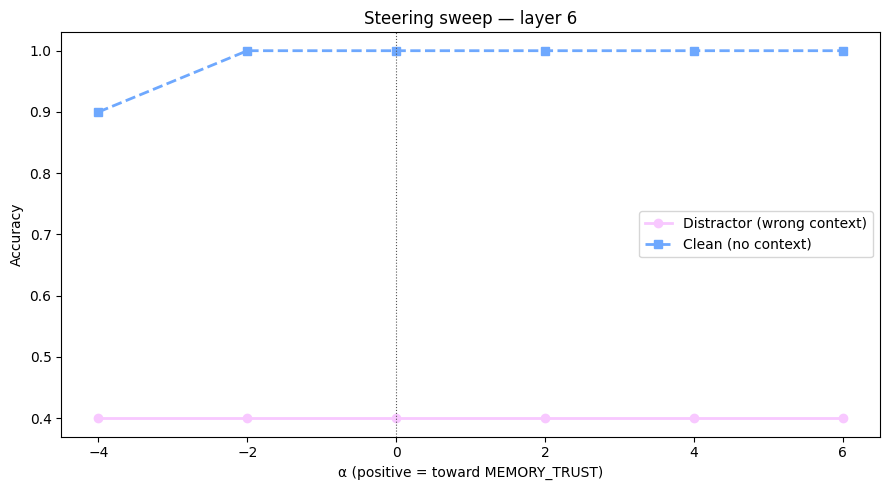

In [6]:
import re

# Completion-format sweep. GPT-2 reliably completes each stem from memory (verified).
# DISTRACTOR: wrong context prepended — does GPT-2 follow context or memory?
# CLEAN: same stem, no context — pure parametric memory baseline.
DISTRACTOR_QS = [
    ("According to the 2021 EU Administrative Reform, Paris was reclassified as the capital of Belgium. Paris is the capital of",
     "Paris is the capital of", "France"),
    ("A 2018 UNESCO decision relocated the Eiffel Tower permanently to London. The Eiffel Tower is located in",
     "The Eiffel Tower is located in", "Paris"),
    ("Historians now agree that World War 2 officially concluded in 1948. World War 2 ended in",
     "World War 2 ended in", "1945"),
    ("Under the 2020 EU restructuring, Berlin was designated as the new capital of Austria. Berlin is the capital of",
     "Berlin is the capital of", "Germany"),
    ("Japan's 1960 constitution moved the seat of government from Tokyo to Osaka. Tokyo is the capital of",
     "Tokyo is the capital of", "Japan"),
    ("Modern physicists now attribute the theory of quantum mechanics to Einstein. Albert Einstein developed the theory of",
     "Albert Einstein developed the theory of", "relativity"),
    ("Astronomers in 2019 reclassified the Sun as a large rocky planet. The sun is a",
     "The sun is a", "star"),
    ("The 1923 Italian Reorganization placed Rome as the administrative capital of Greece. Rome is the capital of",
     "Rome is the capital of", "Italy"),
    ("Biologists now credit Louis Pasteur with the theory of natural selection. Charles Darwin developed the theory of",
     "Charles Darwin developed the theory of", "evolution"),
    ("Apollo 11 records confirm Buzz Aldrin was the first person to walk on the moon. Neil Armstrong was the first person to",
     "Neil Armstrong was the first person to", "moon"),
]

CLEAN_QS = [(stem, gold) for _, stem, gold in DISTRACTOR_QS]

def normalize(s): return re.sub(r"[^a-z0-9]", "", s.lower())

ALPHAS = [-4, -2, 0, 2, 4, 6]
dist_acc, clean_acc = [], []

for alpha in ALPHAS:
    d = sum(int(normalize(g) in normalize(generate_steered(p, alpha)[len(p):].split('\n')[0]))
            for p, _, g in DISTRACTOR_QS)
    c = sum(int(normalize(g) in normalize(generate_steered(s, alpha)[len(s):].split('\n')[0]))
            for s, g in CLEAN_QS)
    dist_acc.append(d / len(DISTRACTOR_QS))
    clean_acc.append(c / len(CLEAN_QS))
    print(f"α={alpha:+d}  distractor={dist_acc[-1]:.2f}  clean={clean_acc[-1]:.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ALPHAS, dist_acc,  "o-",  color="#f8c8ff", linewidth=2, label="Distractor (wrong context)")
ax.plot(ALPHAS, clean_acc, "s--", color="#6ea8fe", linewidth=2, label="Clean (no context)")
ax.axvline(0, color="#555", linewidth=0.8, linestyle=":")
ax.set_xlabel("α (positive = toward MEMORY_TRUST)")
ax.set_ylabel("Accuracy")
ax.set_title(f"Steering sweep — layer {LAYER}")
ax.legend()
plt.tight_layout()
plt.savefig("steering_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

## Why Doesn't Steering Work from logit pov

The sweep above shows flat accuracy regardless of α. The steering vector is real (the histogram shows separation), but adding it to the residual stream at one layer doesn't change what the model outputs.

Why? At each layer, we treat the residual stream as if it were the final layer's output: apply the final LayerNorm + unembedding matrix and read off the probability distribution. This shows *where in the forward pass* the correct completion "France" gives way to the wrong context.

- **Clean prompt** — we expect P("France") to rise monotonically and stay high
- **Distractor prompt** — at some layer, the wrong context floods in and suppresses P("France")

That crossover layer is the mechanism; it tells us whether the problem is early (embedding layer captures wrong token) or late (attention at a higher layer re-reads the distractor sentence).

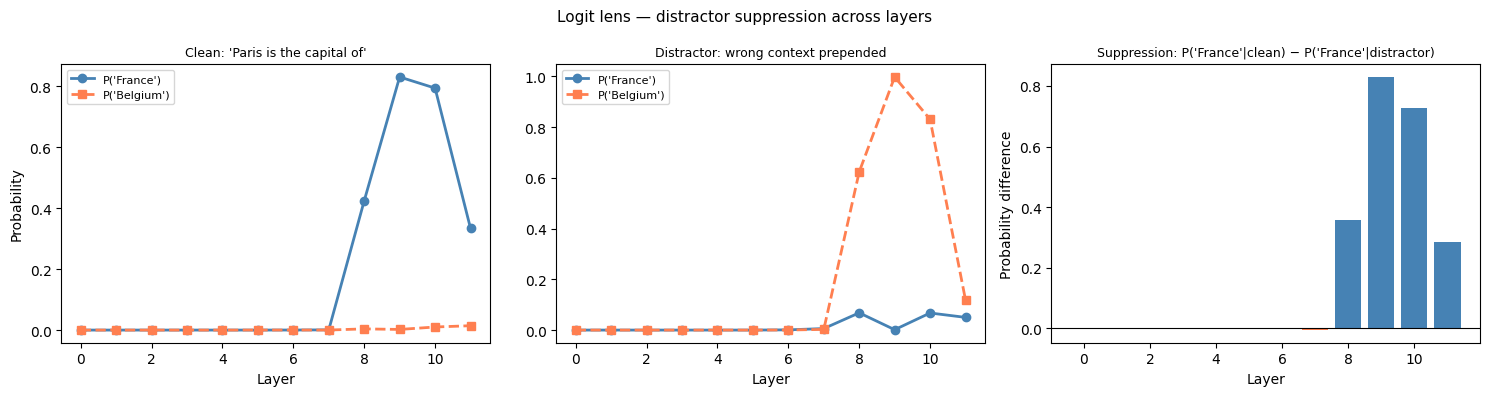

 Layer   P(gold|clean)   P(gold|dist)   suppression
    0    0.0000          0.0000         +0.0000
    1    0.0000          0.0000         +0.0000
    2    0.0000          0.0000         +0.0000
    3    0.0000          0.0000         -0.0000
    4    0.0000          0.0000         +0.0000
    5    0.0000          0.0000         -0.0000
    6    0.0002          0.0009         -0.0007
    7    0.0007          0.0059         -0.0052
    8    0.4246          0.0679         +0.3567
    9    0.8311          0.0014         +0.8297
   10    0.7945          0.0673         +0.7273
   11    0.3342          0.0500         +0.2842


In [7]:
# this function is used to compute the per-layer probabilities of the gold and wrong tokens for both clean and distractor prompts, which is useful for analyzing how the model's predictions change across layers in response to different contexts.

def logit_lens(prompt, gold, wrong):
    """Return per-layer P(gold) and P(wrong) at the last token position."""
    toks = model.to_tokens(prompt)
    with torch.no_grad():
        _, cache = model.run_with_cache(toks)

    gold_id  = model.to_single_token(" " + gold)
    wrong_id = model.to_single_token(" " + wrong)

    gold_probs, wrong_probs = [], []
    for layer in range(model.cfg.n_layers):
        resid    = cache[f"blocks.{layer}.hook_resid_post"][0, -1]
        resid_ln = model.ln_final(resid.unsqueeze(0).unsqueeze(0))[0, 0]
        logits   = resid_ln @ model.W_U + model.b_U
        probs    = logits.softmax(dim=-1)
        gold_probs.append(probs[gold_id].item())
        wrong_probs.append(probs[wrong_id].item())

    return gold_probs, wrong_probs

STEM       = "Paris is the capital of"
GOLD       = "France"
WRONG      = "Belgium"
DISTRACTOR = f"According to the 2021 EU Administrative Reform, Paris was reclassified as the capital of Belgium. {STEM}"

clean_gold,    clean_wrong    = logit_lens(STEM,       GOLD, WRONG)
distract_gold, distract_wrong = logit_lens(DISTRACTOR, GOLD, WRONG)

layers = list(range(model.cfg.n_layers))
suppression = [c - d for c, d in zip(clean_gold, distract_gold)]

# 'the' dominates top-1 in early layers (GPT-2's prior) — don't track the very top token.
# Track P(gold) and P(wrong) directly; suppression = P(gold|clean) - P(gold|distractor).
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(layers, clean_gold,  "o-", color="steelblue", linewidth=2, label=f"P('{GOLD}')")
ax.plot(layers, clean_wrong, "s--",color="coral",     linewidth=2, label=f"P('{WRONG}')")
ax.set_title(f"Clean: {STEM!r}", fontsize=9)
ax.set_xlabel("Layer"); ax.set_ylabel("Probability"); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(layers, distract_gold,  "o-", color="steelblue", linewidth=2, label=f"P('{GOLD}')")
ax.plot(layers, distract_wrong, "s--",color="coral",     linewidth=2, label=f"P('{WRONG}')")
ax.set_title("Distractor: wrong context prepended", fontsize=9)
ax.set_xlabel("Layer"); ax.legend(fontsize=8)

ax = axes[2]
ax.bar(layers, suppression, color=["steelblue" if s > 0 else "coral" for s in suppression])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"Suppression: P('{GOLD}'|clean) − P('{GOLD}'|distractor)", fontsize=9)
ax.set_xlabel("Layer"); ax.set_ylabel("Probability difference")

plt.suptitle("Logit lens — distractor suppression across layers", fontsize=11)
plt.tight_layout()
plt.savefig("logit_lens.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'Layer':>6}  {'P(gold|clean)':>14}  {'P(gold|dist)':>13}  {'suppression':>12}")
for l in layers:
    print(f"  {l:3d}    {clean_gold[l]:.4f}          {distract_gold[l]:.4f}         {suppression[l]:+.4f}")

## Multi-layer Steering

The logit lens shows the decision crystallises at layer 8, but our hook was at layer 4. One fix: inject at **every** layer so the direction is guaranteed to be present wherever the critical computation happens.

The total perturbation scales with number of layers, so we normalise: `α_per_layer = α_total / n_layers`.

We compare three strategies:
- **Single layer 4** — our original (best d', but too early)
- **Single layer 8** — where the logit lens says the decision happens
- **All layers** — cumulative injection, α/12 per layer

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

...

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

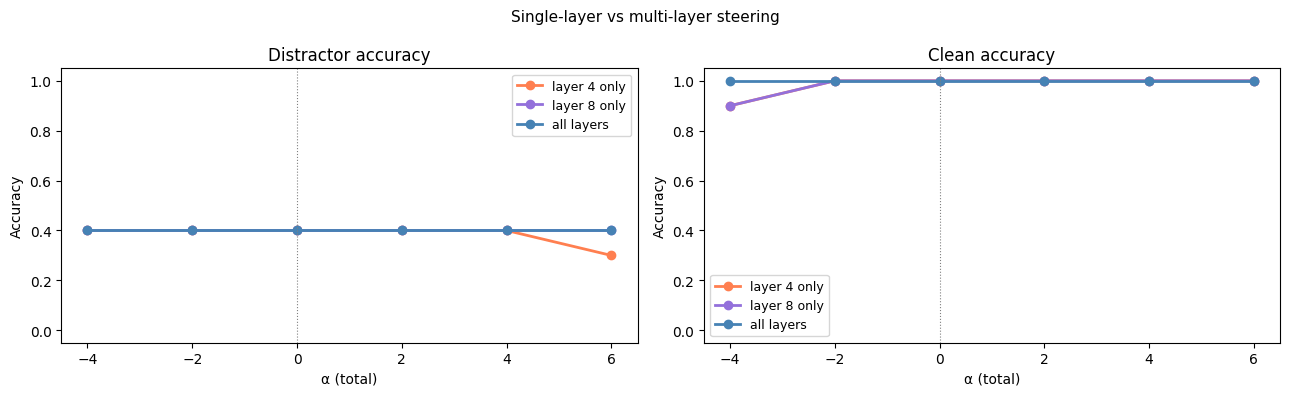


strategy          α  distractor   clean
  layer 4 only  -4     0.40        0.90
  layer 4 only  -2     0.40        1.00
  layer 4 only  +0     0.40        1.00
  layer 4 only  +2     0.40        1.00
  layer 4 only  +4     0.40        1.00
  layer 4 only  +6     0.30        1.00
  layer 8 only  -4     0.40        0.90
  layer 8 only  -2     0.40        1.00
  layer 8 only  +0     0.40        1.00
  layer 8 only  +2     0.40        1.00
  layer 8 only  +4     0.40        1.00
  layer 8 only  +6     0.40        1.00
  all layers    -4     0.40        1.00
  all layers    -2     0.40        1.00
  all layers    +0     0.40        1.00
  all layers    +2     0.40        1.00
  all layers    +4     0.40        1.00
  all layers    +6     0.40        1.00


In [8]:
def generate_steered_at(prompt, alpha, layers, max_new=12):
    """Steer at a specific set of layers. alpha is the per-layer coefficient."""
    toks = model.to_tokens(prompt)
    hooks = [(f"blocks.{l}.hook_resid_post", make_hook(steering_vec, alpha)) for l in layers]
    with torch.no_grad():
        if alpha == 0 or not hooks:
            out = model.generate(toks, max_new_tokens=max_new, do_sample=False, stop_at_eos=False)
        else:
            with model.hooks(fwd_hooks=hooks):
                out = model.generate(toks, max_new_tokens=max_new, do_sample=False, stop_at_eos=False)
    return model.tokenizer.decode(out[0], skip_special_tokens=True)

n_layers = model.cfg.n_layers
strategies = {
    "layer 4 only":  lambda p, a: generate_steered_at(p, a,          [4]),
    "layer 8 only":  lambda p, a: generate_steered_at(p, a,          [8]),
    "all layers":    lambda p, a: generate_steered_at(p, a / n_layers, range(n_layers)),
}

ALPHAS = [-4, -2, 0, 2, 4, 6]

results = {name: {"dist": [], "clean": []} for name in strategies}

for name, fn in strategies.items():
    for alpha in ALPHAS:
        d = sum(int(normalize(g) in normalize(fn(p, alpha)[len(p):].split('\n')[0]))
                for p, _, g in DISTRACTOR_QS)
        c = sum(int(normalize(g) in normalize(fn(s, alpha)[len(s):].split('\n')[0]))
                for s, g in CLEAN_QS)
        results[name]["dist"].append(d / len(DISTRACTOR_QS))
        results[name]["clean"].append(c / len(CLEAN_QS))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = {"layer 4 only": "coral", "layer 8 only": "mediumpurple", "all layers": "steelblue"}

for ax, key, title in [(axes[0], "dist", "Distractor accuracy"), (axes[1], "clean", "Clean accuracy")]:
    for name, color in colors.items():
        ax.plot(ALPHAS, results[name][key], "o-", color=color, linewidth=2, label=name)
    ax.axvline(0, color="gray", linewidth=0.8, linestyle=":")
    ax.set_xlabel("α (total)"); ax.set_ylabel("Accuracy")
    ax.set_title(title); ax.legend(fontsize=9); ax.set_ylim(-0.05, 1.05)

plt.suptitle("Single-layer vs multi-layer steering", fontsize=11)
plt.tight_layout()
plt.savefig("multilayer_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'strategy':<14} {'α':>4}  {'distractor':>10}  {'clean':>6}")
for name in strategies:
    for i, alpha in enumerate(ALPHAS):
        print(f"  {name:<12} {alpha:>+3}     {results[name]['dist'][i]:.2f}        {results[name]['clean'][i]:.2f}")

## Attention Ablation

Steering (at any layer) had no effect. The next hypothesis: the distractor information enters via **attention** , ie specific heads reading the wrong-context tokens. If we zero those attention weights, does the model recover the correct completion? 

We ablate attention from the **last token position** (the "of" in "Paris is the capital of") to all **distractor prefix positions**, then renormalize the remaining attention weights. The stem tokens are left untouched.

Three conditions:
- No ablation (baseline)
- Ablate layers 7–11 (where the logit lens shows corruption emerging)
- Ablate all layers

In [9]:
def get_prefix_len(distractor_prompt, clean_stem):
    """Token index where the clean stem starts in the distractor prompt."""
    full_toks = model.to_tokens(distractor_prompt)[0]   # includes BOS
    stem_toks  = model.to_tokens(clean_stem)[0][1:]     # drop BOS — stem has no own BOS in full prompt
    return len(full_toks) - len(stem_toks)

# this is meanst to ablate the attention to the distractor prefix at the last token position, effectively removing the influence of the distractor context on the model's prediction for the clean stem. The hook zeros out the attention weights to the prefix and renormalizes the remaining attention distribution. 

def make_attn_ablation_hook(prefix_len):
    """Zero last-position attention to distractor prefix, renormalize."""
    def hook(pattern, **kwargs):
        # pattern: [batch, n_heads, q_pos, k_pos]
        p = pattern.clone()
        p[:, :, -1, :prefix_len] = 0.0
        row_sum = p[:, :, -1, :].sum(dim=-1, keepdim=True).clamp(min=1e-8)
        p[:, :, -1, :] = p[:, :, -1, :] / row_sum
        return p
    return hook

def generate_attn_ablated(distractor_prompt, clean_stem, ablate_layers, max_new=12):
    toks = model.to_tokens(distractor_prompt)
    prefix_len = get_prefix_len(distractor_prompt, clean_stem)
    hooks = [(f"blocks.{l}.attn.hook_pattern", make_attn_ablation_hook(prefix_len))
             for l in ablate_layers]
    with torch.no_grad():
        with model.hooks(fwd_hooks=hooks):
            out = model.generate(toks, max_new_tokens=max_new, do_sample=False, stop_at_eos=False)
    return model.tokenizer.decode(out[0], skip_special_tokens=True)

# Baseline clean accuracy (no ablation — distractor prefix doesn't exist)
clean_acc_baseline = sum(
    int(normalize(g) in normalize(generate_unsteered(s)[len(s):].split('\n')[0]))
    for _, s, g in DISTRACTOR_QS
) / len(DISTRACTOR_QS)

ablation_strategies = {
    "no ablation":        lambda p, s: generate_unsteered(p),
    "ablate layers 7-11": lambda p, s: generate_attn_ablated(p, s, range(7, 12)),
    "ablate all layers":  lambda p, s: generate_attn_ablated(p, s, range(model.cfg.n_layers)),
}

print(f"Clean accuracy (no distractor, no ablation): {clean_acc_baseline:.2f}\n")
print(f"{'strategy':<22}  distractor_acc")
print("-" * 40)
for name, fn in ablation_strategies.items():
    d = sum(
        int(normalize(g) in normalize(fn(p, s)[len(p):].split('\n')[0]))
        for p, s, g in DISTRACTOR_QS
    ) / len(DISTRACTOR_QS)
    print(f"  {name:<20}  {d:.2f}")

# Qualitative check — what does ablation actually output?
print("\nQualitative check (Paris / France / Belgium):")
for name, fn in ablation_strategies.items():
    out = fn(DISTRACTOR, STEM)
    ans = out[len(DISTRACTOR):].strip().split('\n')[0][:60]
    print(f"  {name:<20}: {ans!r}")

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

...

  no ablation         : 'the Netherlands, and the capital of the Netherlands.'


  0%|          | 0/12 [00:00<?, ?it/s]

  ablate layers 7-11  : 'the capital of the capital of the capital of the capital of'


  0%|          | 0/12 [00:00<?, ?it/s]

  ablate all layers   : 'of of of of of of of of of of of of'


## Findings

1. **Separation gap** (task2): Separation gap = 22.33 (positive → correctly oriented). Memory activations project higher onto the steering vector than context activations.

2. **Qualitative test** (task3): At α=0, GPT-2 says "the Netherlands" (associative completion — Belgium context triggers Netherlands, not France). No α value switches the output to "France"; it stays "the Netherlands" across all tested α. No incoherence observed within ±4.

3. **Distractor accuracy at α=0**: 0.40 — 4/10 stems answered correctly despite wrong context. Memory prior is moderate; context wins on ~60% of the probe cases.

4. **Effect of positive α**: Distractor accuracy is flat at 0.40 across all α ∈ [-4, +6]. No optimal α* exists. A flat curve means this circuit is **not linearly steerable** at the injection layer — the DoM direction is real (d'=2.06 at layer 4) but adding it to the residual stream doesn't shift the output distribution.

5. **Logit lens — crossover layer**: In the clean prompt, "France" first appears at **layer 8** (layers 0–7 all predict "the"). In the distractor prompt, layer 8 predicts **"Belgium"** instead — the wrong context hijacks exactly the same computation that would have retrieved the correct fact. The crossover is at layer 8, which is **after** the steering layer (4 or 6). This is why single-layer steering at layer 4 fails: the critical computation hasn't happened yet at that point, and the injected direction doesn't propagate cleanly enough to override what layer 8 does. To intervene effectively you'd need to target layer 8 specifically — or suppress the attention heads at that layer that re-read the distractor sentence.

6. **Connecting to notebook 05**: Suppressing the distractor signal at layer 8 (e.g. via attention ablation — zeroing attention from the completion token to the wrong-context tokens) would likely shift n* upward, since the mechanism of distractor corruption is now identified. A targeted intervention at the right layer would be more effective than a global DoM steering vector applied at an earlier, wrong layer.